# Notebook 1: EDA e Tratamento de Dados

**Objetivo**: Explorar, limpar e preparar os dados do dataset Heart Disease para modelagem.

**O que você vai fazer neste notebook:**
1. Carregar dados brutos
2. Exploração e visualização (EDA)
3. Identificar e tratar dados faltantes
4. Identificar e tratar outliers
5. Normalizar/padronizar features
6. Encodeamento de variáveis categóricas
7. Salvar dados tratados em CSV

---

## PASSO 1: Importar Bibliotecas

Importe todas as bibliotecas necessárias para análise de dados:
- `pandas`: manipulação de dados
- `numpy`: operações numéricas
- `matplotlib` e `seaborn`: visualização
- `scikit-learn`: pré-processamento e modelagem

**TODO:** Execute a célula abaixo e adicione qualquer importação necessária que esteja faltando.


In [63]:
# Importe as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

## PASSO 2: Carregar e Explorar os Dados

**TODO:**
1. Carregar o dataset usando a lib do site (https://archive.ics.uci.edu/dataset/45/heart+disease)
2. Use `df.info()` para ver tipos de dados
3. Use `df.describe()` para estatísticas básicas
4. Use `df.head()` para ver as primeiras linhas
5. Imprima o shape (linhas, colunas)

**Dica**: Sempre comece explorando seus dados!

In [64]:
#instalando a biblieoteca ucimlrepo para acessar datasets do UCI Machine Learning Repository
!pip install ucimlrepo


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

## 📊 Dicionário de Dados

| Variável   | Tipo         | Descrição                                                                 | Unidade   | Observações |
|------------|-------------|--------------------------------------------------------------------------|----------|------------|
| `age`      | Inteiro     | Idade do paciente                                                        | anos     | — |
| `sex`      | Categórica  | Sexo do paciente                                                         | —        | — |
| `cp`       | Categórica  | Tipo de dor no peito                                                     | —        | — |
| `trestbps` | Inteiro     | Pressão arterial em repouso (na admissão hospitalar)                     | mm Hg    | — |
| `chol`     | Inteiro     | Colesterol sérico                                                        | mg/dl    | — |
| `fbs`      | Categórica  | Açúcar no sangue em jejum > 120 mg/dl                                    | —        | — |
| `restecg`  | Categórica  | Resultados do eletrocardiograma em repouso                               | —        | — |
| `thalach`  | Inteiro     | Frequência cardíaca máxima atingida                                      | —        | — |
| `exang`    | Categórica  | Angina induzida por exercício                                            | —        | — |
| `oldpeak`  | Float       | Depressão do segmento ST induzida por exercício em relação ao repouso    | —        | — |
| `slope`    | Categórica  | Inclinação do segmento ST no pico do exercício                           | —        | — |
| `ca`       | Inteiro     | Número de vasos principais (0–3) coloridos por fluoroscopia              | —        | Possui valores ausentes |
| `thal`     | Categórica  | Resultado do teste de talassemia                                         | —        | Possui valores ausentes |
| `num`      | Inteiro     | Diagnóstico de doença cardíaca                                           | —        | Variável alvo (target) |

---

## 🎯 Variável Alvo

- `num`:
  - 0 → Sem doença cardíaca  
  - 1–4 → Presença de doença cardíaca (diferentes níveis de severidade)

In [66]:
# renomeando a coluna de num para "target" e exibindo as primeiras linhas
y = y.rename(columns={"num": "target"})
y.head()

,target
0,0
1,2
2,1
3,0
4,0


In [67]:
# concatenar X e y para análise exploratória
df=pd.concat([X, y], axis=1)
df['target'] = df['target'].apply(lambda x: 0 if x == 0 else 1)
# TODO: Imprima as informações básicas
# Use:
# - print(f"Shape: {df.shape}")
# - df.head() para ver primeiras linhas
# - df.info() para ver tipos de dados
# - df.describe() para ver estatísticas
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## PASSO 3: Verificar Dados Faltantes

**TODO:**
1. Conte quantos valores faltantes existem em cada coluna
2. Visualize isso em um gráfico
3. Decida a estratégia: remover, preencher com média/mediana ou remover coluna


In [68]:
# PASSO 3.1: Verificar dados faltantes
print("=" * 60)
print("DADOS FALTANTES")
print("=" * 60)

# TODO: Use df.isnull().sum() para contar valores faltantes
df.isnull().sum()
# TODO: Use df.dropna() para remover linhas com dados faltantes (se necessário)
df.dropna(inplace=True)
df.info()

DADOS FALTANTES
<class 'pandas.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    int64  
 1   sex       297 non-null    int64  
 2   cp        297 non-null    int64  
 3   trestbps  297 non-null    int64  
 4   chol      297 non-null    int64  
 5   fbs       297 non-null    int64  
 6   restecg   297 non-null    int64  
 7   thalach   297 non-null    int64  
 8   exang     297 non-null    int64  
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    int64  
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 34.8 KB


## PASSO 4: Análise Exploratória (EDA)

**TODO:**
1. Analise a distribuição da variável target (doença cardíaca)
2. Crie gráficos de distribuição para as principais features
3. Analise a correlação entre variáveis
4. Identifique relações entre features e target


DISTRIBUIÇÃO DA VARIÁVEL TARGET

Contagem de classes:
target
0    160
1    137
Name: count, dtype: int64

Proporção de classes:
target
0    0.54
1    0.46
Name: proportion, dtype: float64


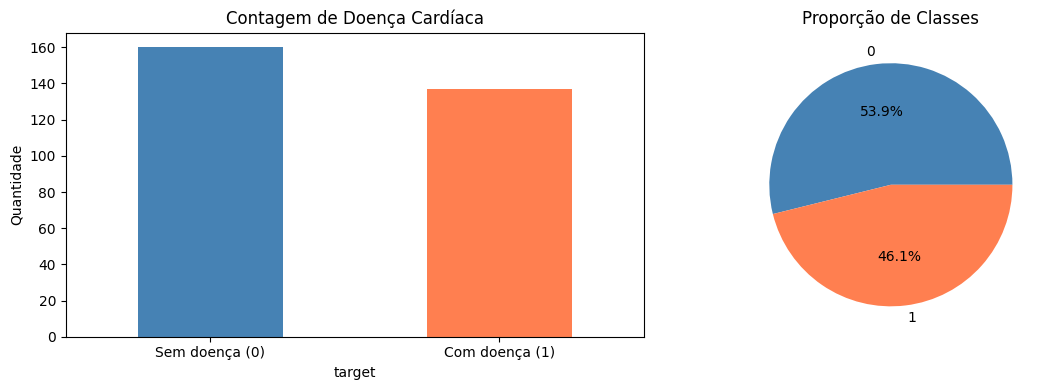


📊 A classe está balanceada? Há aproximadamente a mesma quantidade de cada classe?


In [69]:
# PASSO 4.1: Distribuição da variável target
print("=" * 60)
print("DISTRIBUIÇÃO DA VARIÁVEL TARGET")
print("=" * 60)

print(f"\nContagem de classes:\n{df['target'].value_counts()}")
print(f"\nProporção de classes:\n{df['target'].value_counts(normalize=True).round(2)}")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Contagem
df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Contagem de Doença Cardíaca')
axes[0].set_ylabel('Quantidade')
axes[0].set_xticklabels(['Sem doença (0)', 'Com doença (1)'], rotation=0)

# Gráfico 2: Proporção
df['target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[1].set_title('Proporção de Classes')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n📊 A classe está balanceada? Há aproximadamente a mesma quantidade de cada classe?")

DISTRIBUIÇÃO DAS FEATURES NUMÉRICAS

Features numéricas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


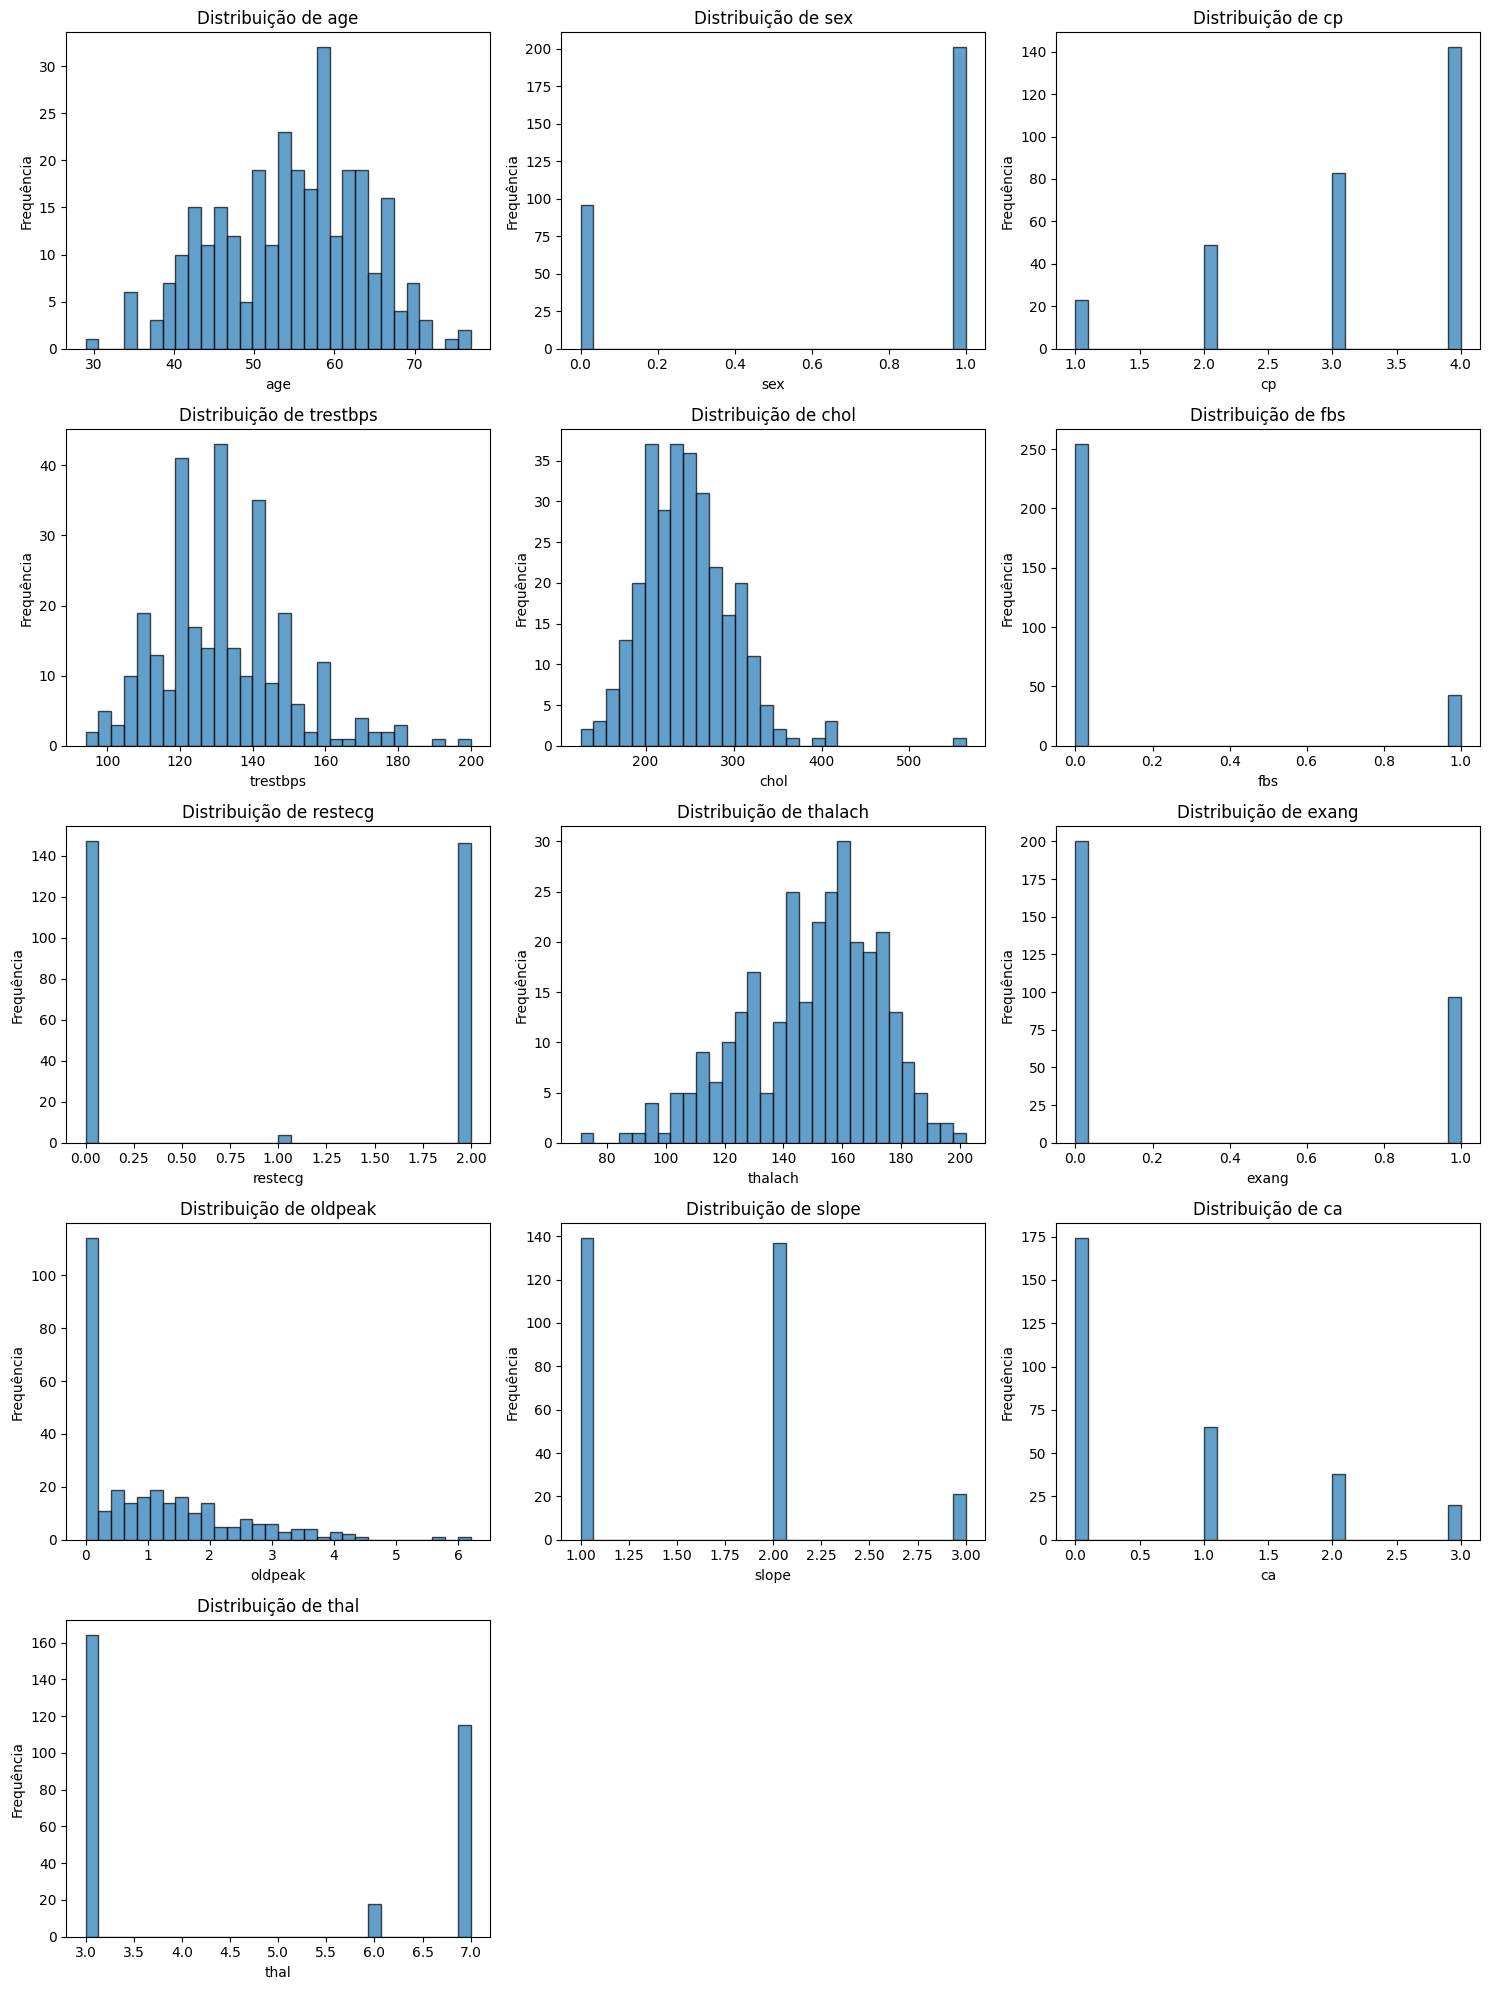


📊 Observações:
- Há features com distribuição normal?
- Há features muito diferentes em escala?
- Há outliers visíveis?


In [70]:
# PASSO 4.2: Distribuição das features numéricas
import math

print("=" * 60)
print("DISTRIBUIÇÃO DAS FEATURES NUMÉRICAS")
print("=" * 60)

# Selecionar features numéricas (excluindo target)
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

if 'target' in numeric_features:
    numeric_features.remove('target')

print(f"\nFeatures numéricas: {numeric_features}")

# Definir layout dinâmico
n_features = len(numeric_features)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

# Criar figura
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.ravel()

# Plotar histogramas
for idx, feature in enumerate(numeric_features):
    axes[idx].hist(df[feature], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribuição de {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequência')

# Remover subplots vazios
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

print("\n📊 Observações:")
print("- Há features com distribuição normal?")
print("- Há features muito diferentes em escala?")
print("- Há outliers visíveis?")

MATRIZ DE CORRELAÇÃO

Correlação com 'target' (doença cardíaca):
target      1.000000
thal        0.526640
ca          0.463189
oldpeak     0.424052
exang       0.421355
cp          0.408945
slope       0.333049
sex         0.278467
age         0.227075
restecg     0.166343
trestbps    0.153490
chol        0.080285
fbs         0.003167
thalach    -0.423817
Name: target, dtype: float64


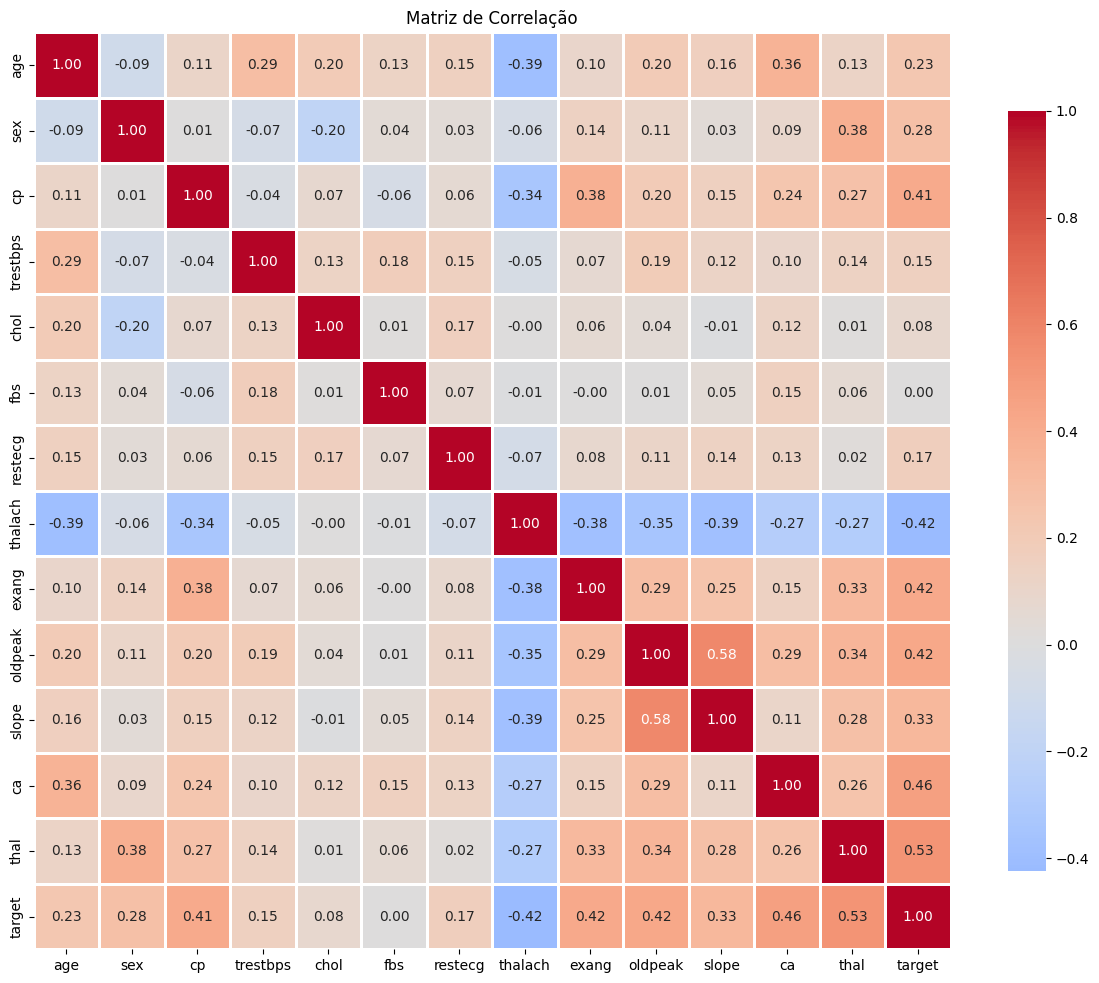


💡 Dica: Features com correlação > 0.5 (ou < -0.5) têm forte relação com a doença cardíaca


In [71]:
# PASSO 4.3: Matriz de Correlação
print("=" * 60)
print("MATRIZ DE CORRELAÇÃO")
print("=" * 60)

# Calcular correlação com .corr()
correlation_matrix = df.corr()

# Visualizar correlação com target
target_corr = correlation_matrix['target'].sort_values(ascending=False)
print(f"\nCorrelação com 'target' (doença cardíaca):\n{target_corr}")

# Heatmap completo
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

print("\n💡 Dica: Features com correlação > 0.5 (ou < -0.5) têm forte relação com a doença cardíaca")

## 🔧 PASSO 5: Tratamento de Dados e Normalização

**TODO:**
1. Aplique normalização/padronização (StandardScaler ou MinMaxScaler)
2. Crie features codificadas (se houver categóricas - aqui todas são numéricas)
3. Verifique se os dados estão prontos


In [72]:
# Preparar os dados para modelagem
print("=" * 60)
print("PREPARAÇÃO DOS DADOS")
print("=" * 60)

# TODO: Separe features (X) e target (y)
# Use df.drop('target', axis=1) para X
# Use df['target'] para y
X = df.drop('target', axis=1)  # COMPLETE
y = df['target']  # COMPLETE

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

PREPARAÇÃO DOS DADOS

Shape de X: (297, 13)
Shape de y: (297,)


In [73]:
# Normalizar/Padronizar as features
# Usaremos StandardScaler que transforma os dados para média=0 e desvio padrão=1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Converter para dataframe para manter os nomes das colunas
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Estatísticas ANTES da normalização:")
print(X.describe().round(2))

print("\n" + "="*60)
print("Estatísticas DEPOIS da normalização:")
print("="*60)
print(X_scaled_df.describe().round(2))

print("\n✓ Dados normalizados! Agora média ≈ 0 e desvio padrão ≈ 1")

Estatísticas ANTES da normalização:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  297.00  297.00  297.00    297.00  297.00  297.00   297.00   297.00   
mean    54.54    0.68    3.16    131.69  247.35    0.14     1.00   149.60   
std      9.05    0.47    0.96     17.76   52.00    0.35     0.99    22.94   
min     29.00    0.00    1.00     94.00  126.00    0.00     0.00    71.00   
25%     48.00    0.00    3.00    120.00  211.00    0.00     0.00   133.00   
50%     56.00    1.00    3.00    130.00  243.00    0.00     1.00   153.00   
75%     61.00    1.00    4.00    140.00  276.00    0.00     2.00   166.00   
max     77.00    1.00    4.00    200.00  564.00    1.00     2.00   202.00   

        exang  oldpeak   slope      ca    thal  
count  297.00   297.00  297.00  297.00  297.00  
mean     0.33     1.06    1.60    0.68    4.73  
std      0.47     1.17    0.62    0.94    1.94  
min      0.00     0.00    1.00    0.00    3.00  
25%      0.00     0.00   

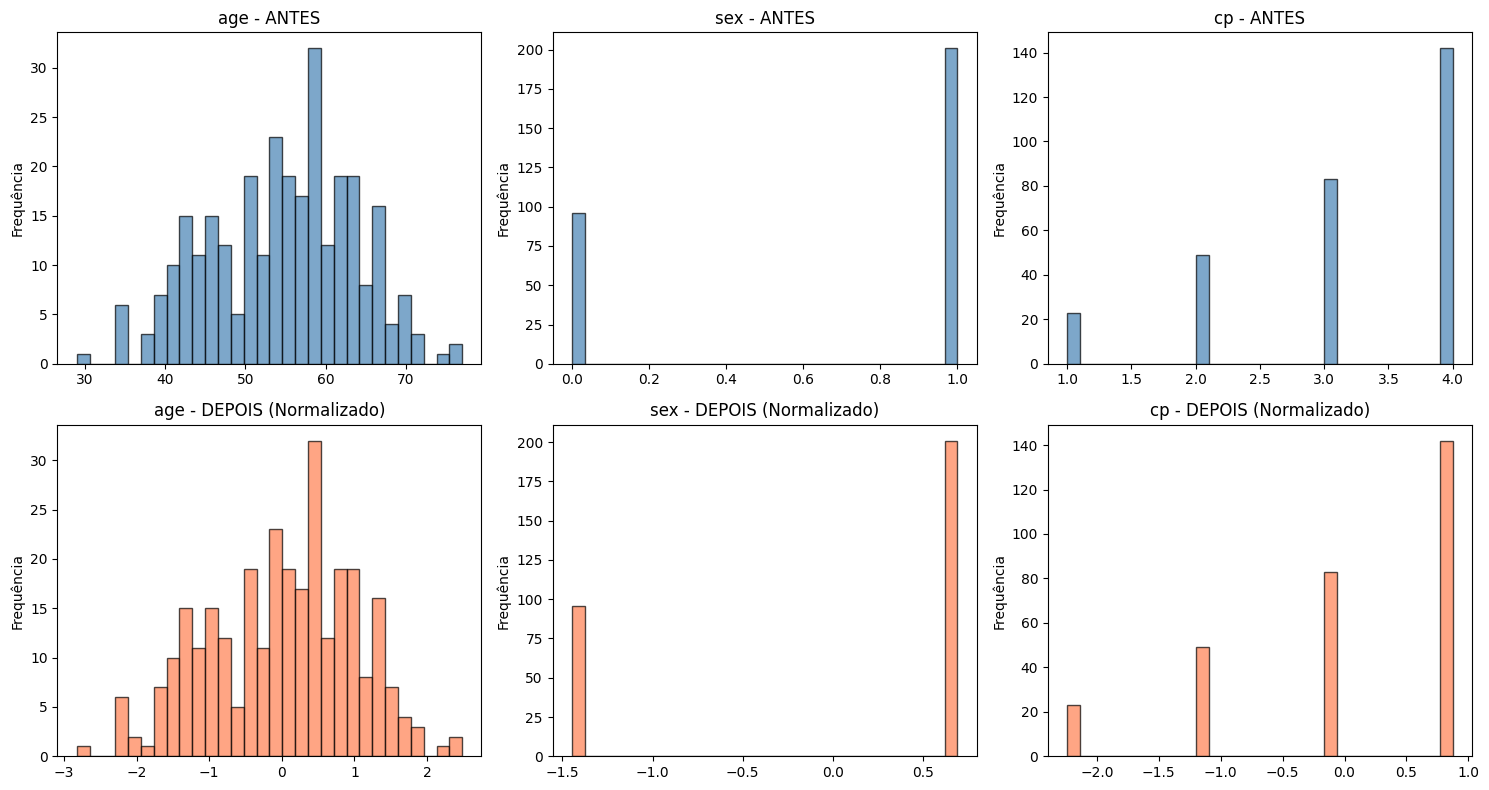

📊 Observe como a escala mudou após a normalização!


In [74]:
# PASSO 6.3: Visualizar antes e depois da normalização
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features_sample = numeric_features[:3]  # Pegar apenas 3 features para visualizar

for idx, feature in enumerate(features_sample):
    # Antes
    axes[0, idx].hist(X[feature], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes[0, idx].set_title(f'{feature} - ANTES')
    axes[0, idx].set_ylabel('Frequência')
    
    # Depois
    axes[1, idx].hist(X_scaled_df[feature], bins=30, alpha=0.7, color='coral', edgecolor='black')
    axes[1, idx].set_title(f'{feature} - DEPOIS (Normalizado)')
    axes[1, idx].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

print("📊 Observe como a escala mudou após a normalização!")

##  PASSO 6: Salvar Dados Processados

**TODO:**
1. Combinar X normalizado com y
2. Salvar em `data/processed/heart_disease_processed.csv`
3. Verificar se foi salvo corretamente


In [75]:
# PASSO 6.1: Combinar dados processados
print("=" * 60)
print("SALVANDO DADOS PROCESSADOS")
print("=" * 60)

# Combinar features normalizadas com target
df_final = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)

print(f"\nShape dos dados finais: {df_final.shape}")
print(f"\nPrimeiras linhas:")
print(df_final.head())
print(f"\nÚltimas linhas:")
print(df_final.tail())

SALVANDO DADOS PROCESSADOS

Shape dos dados finais: (297, 14)

Primeiras linhas:
        age       sex        cp  trestbps      chol       fbs   restecg  \
0  0.936181  0.691095 -2.240629  0.750380 -0.276443  2.430427  1.010199   
1  1.378929  0.691095  0.873880  1.596266  0.744555 -0.411450  1.010199   
2  1.378929  0.691095  0.873880 -0.659431 -0.353500 -0.411450  1.010199   
3 -1.941680  0.691095 -0.164289 -0.095506  0.051047 -0.411450 -1.003419   
4 -1.498933 -1.446980 -1.202459 -0.095506 -0.835103 -0.411450  1.010199   

    thalach     exang   oldpeak     slope        ca      thal  target  
0  0.017494 -0.696419  1.068965  2.264145 -0.721976  0.655877       0  
1 -1.816334  1.435916  0.381773  0.643781  2.478425 -0.894220       1  
2 -0.899420  1.435916  1.326662  0.643781  1.411625  1.172577       1  
3  1.633010 -0.696419  2.099753  2.264145 -0.721976 -0.894220       0  
4  0.978071 -0.696419  0.295874 -0.976583 -0.721976 -0.894220       0  

Últimas linhas:
          age      

In [76]:
# PASSO 6.2: Salvar em CSV
# Caminho de saída
output_path = '../data/processed/heart_disease_processed.csv'

# Salvar
df_final.to_csv(output_path, index=False)

print(f"✓ Arquivo salvo em: {output_path}")
print(f"\nVerificação:")

# Verificar se foi salvo
df_check = pd.read_csv(output_path)
print(f"Shape do arquivo salvo: {df_check.shape}")
print(f"Colunas: {list(df_check.columns)}")
print(f"\nPrimeiras linhas do arquivo salvo:")
print(df_check.head())

✓ Arquivo salvo em: ../data/processed/heart_disease_processed.csv

Verificação:
Shape do arquivo salvo: (297, 14)
Colunas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Primeiras linhas do arquivo salvo:
        age       sex        cp  trestbps      chol       fbs   restecg  \
0  0.936181  0.691095 -2.240629  0.750380 -0.276443  2.430427  1.010199   
1  1.378929  0.691095  0.873880  1.596266  0.744555 -0.411450  1.010199   
2  1.378929  0.691095  0.873880 -0.659431 -0.353500 -0.411450  1.010199   
3 -1.941680  0.691095 -0.164289 -0.095506  0.051047 -0.411450 -1.003419   
4 -1.498933 -1.446980 -1.202459 -0.095506 -0.835103 -0.411450  1.010199   

    thalach     exang   oldpeak     slope        ca      thal  target  
0  0.017494 -0.696419  1.068965  2.264145 -0.721976  0.655877       0  
1 -1.816334  1.435916  0.381773  0.643781  2.478425 -0.894220       1  
2 -0.899420  1.435916  1.326662  0.643781  1.411625


### ✓ Tasks Completadas:
1. **Carregamento**: Importou dados brutos do CSV
2. **Exploração**: Analisou shape, tipos de dados e estatísticas básicas
3. **Verificação**: Checou dados faltantes (havia nenhum ou poucos)
4. **EDA**: Visualizou distribuições, correlações e padrões
5. **Normalização**: Padronizou todas as features numéricas
6. **Exportação**: Salvou os dados processados em CSV

### Próxico Passo:
Abra o notebook `02_Treino_e_Avaliacao.ipynb` para completar a segunda etapa:
- Carregue os dados processados
- Treine um modelo de classificação
- Avalie e analise os resultados

---